# Montgomery County Crime Data Analysis (2018–2022)
### Applied Data Programming — Coursework 1
This notebook performs preliminary data exploration, cleaning checks, and visualization for the Montgomery County Crime dataset, supporting the research questions and hypotheses defined in the written report.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid", palette="Set2")

In [7]:
df = pd.read_csv("sample_data/crime_clean.csv")
df.head()

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,...,consistency_score,validity_score,quality_score,quality_tier,Primary Offense,year,month,weekday,hour,District_Norm
0,201175193,2399,180007927,2018-02-15 12:54:11,23H,1,Crime Against Property,All Other Larceny,Larceny (Describe Offense),Silver Spring,...,100.0,80.0,94.0,Excellent,Crime Against Property,2018.0,1.0,Monday,0.0,Silver Spring
1,201205763,2308,180045732,2018-09-13 12:48:16,23D,1,Crime Against Property,Theft From Building,Larceny - From Bldg,Rockville,...,70.0,80.0,85.0,Good,Crime Against Property,2018.0,1.0,Monday,12.0,Rockville
2,201169410,5404,180000017,2018-01-01 02:15:26,90D,1,Crime Against Society,Driving Under The Influence,Driving Under The Influence Liquor,Germantown,...,100.0,80.0,94.0,Excellent,Crime Against Society,2018.0,1.0,Monday,2.0,Germantown
3,201168935,2902,180000064,2018-01-01 11:16:40,290,1,Crime Against Property,Destruction/Damage/Vandalism Of Property,Damage Property - Private,Germantown,...,100.0,80.0,94.0,Excellent,Crime Against Property,2018.0,1.0,Monday,1.0,Germantown
4,201174674,5311,180004168,2018-01-25 00:14:22,90C,1,Crime Against Society,Disorderly Conduct,Public Peace - Disorderly Conduct,Silver Spring,...,100.0,80.0,94.0,Excellent,Crime Against Society,2018.0,1.0,Monday,1.0,Silver Spring


## 1. Dataset Overview
Checking structure, missing values, and column types.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108993 entries, 0 to 108992
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Incident ID             108993 non-null  int64  
 1   Offence Code            108993 non-null  object 
 2   CR Number               108993 non-null  int64  
 3   Dispatch Date / Time    107078 non-null  object 
 4   NIBRS Code              108993 non-null  object 
 5   Victims                 108993 non-null  int64  
 6   Crime Name1             108993 non-null  object 
 7   Crime Name2             108993 non-null  object 
 8   Crime Name3             108993 non-null  object 
 9   Police District Name    108993 non-null  object 
 10  Block Address           108993 non-null  object 
 11  City                    108993 non-null  object 
 12  State                   108993 non-null  object 
 13  Zip Code                108993 non-null  object 
 14  Agency              

In [9]:
df.describe(include='all')

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,...,consistency_score,validity_score,quality_score,quality_tier,Primary Offense,year,month,weekday,hour,District_Norm
count,1.089930e+05,108993.0,1.089930e+05,107078,108993,108993.000000,108993,108993,108993,108993,...,108992.000000,108992.0,108992.000000,108992,108992,108992.000000,108992.000000,108992,108992.000000,108992
unique,NaN,505.0,NaN,106715,56,NaN,6,58,295,10,...,NaN,NaN,NaN,3,6,NaN,NaN,7,NaN,10
top,NaN,2305.0,NaN,2019-12-02 16:39:39,90Z,NaN,Crime Against Property,All Other Offenses,Larceny - From Auto,Silver Spring,...,NaN,NaN,NaN,Excellent,Crime Against Property,NaN,NaN,Friday,NaN,Silver Spring
freq,NaN,12840.0,NaN,47,23323,NaN,62191,22556,15085,22970,...,NaN,NaN,NaN,102476,62191,NaN,NaN,16960,NaN,22970
mean,2.012632e+08,NaN,1.945565e+08,NaN,NaN,1.016707,NaN,NaN,NaN,NaN,...,98.712153,80.0,93.576258,NaN,NaN,2019.432729,6.013065,NaN,13.261845,NaN
std,6.626069e+04,NaN,1.400122e+07,NaN,NaN,0.160755,NaN,NaN,NaN,NaN,...,5.687946,0.0,1.783902,NaN,NaN,1.373350,3.307331,NaN,6.774185,NaN
min,2.011689e+08,NaN,1.800969e+07,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,50.000000,80.0,69.000000,NaN,NaN,2018.000000,1.000000,NaN,0.000000,NaN
25%,2.011990e+08,NaN,1.800371e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,100.000000,80.0,94.000000,NaN,NaN,2018.000000,3.000000,NaN,9.000000,NaN
50%,2.012576e+08,NaN,1.900449e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,100.000000,80.0,94.000000,NaN,NaN,2019.000000,6.000000,NaN,14.000000,NaN
75%,2.013193e+08,NaN,2.100049e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,100.000000,80.0,94.000000,NaN,NaN,2021.000000,9.000000,NaN,19.000000,NaN


In [10]:
df.describe(include='all')

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,...,consistency_score,validity_score,quality_score,quality_tier,Primary Offense,year,month,weekday,hour,District_Norm
count,1.089930e+05,108993.0,1.089930e+05,107078,108993,108993.000000,108993,108993,108993,108993,...,108992.000000,108992.0,108992.000000,108992,108992,108992.000000,108992.000000,108992,108992.000000,108992
unique,NaN,505.0,NaN,106715,56,NaN,6,58,295,10,...,NaN,NaN,NaN,3,6,NaN,NaN,7,NaN,10
top,NaN,2305.0,NaN,2019-12-02 16:39:39,90Z,NaN,Crime Against Property,All Other Offenses,Larceny - From Auto,Silver Spring,...,NaN,NaN,NaN,Excellent,Crime Against Property,NaN,NaN,Friday,NaN,Silver Spring
freq,NaN,12840.0,NaN,47,23323,NaN,62191,22556,15085,22970,...,NaN,NaN,NaN,102476,62191,NaN,NaN,16960,NaN,22970
mean,2.012632e+08,NaN,1.945565e+08,NaN,NaN,1.016707,NaN,NaN,NaN,NaN,...,98.712153,80.0,93.576258,NaN,NaN,2019.432729,6.013065,NaN,13.261845,NaN
std,6.626069e+04,NaN,1.400122e+07,NaN,NaN,0.160755,NaN,NaN,NaN,NaN,...,5.687946,0.0,1.783902,NaN,NaN,1.373350,3.307331,NaN,6.774185,NaN
min,2.011689e+08,NaN,1.800969e+07,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,50.000000,80.0,69.000000,NaN,NaN,2018.000000,1.000000,NaN,0.000000,NaN
25%,2.011990e+08,NaN,1.800371e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,100.000000,80.0,94.000000,NaN,NaN,2018.000000,3.000000,NaN,9.000000,NaN
50%,2.012576e+08,NaN,1.900449e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,100.000000,80.0,94.000000,NaN,NaN,2019.000000,6.000000,NaN,14.000000,NaN
75%,2.013193e+08,NaN,2.100049e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,100.000000,80.0,94.000000,NaN,NaN,2021.000000,9.000000,NaN,19.000000,NaN


In [11]:
df.isnull().sum()

,0
Incident ID,0
Offence Code,0
CR Number,0
Dispatch Date / Time,1915
NIBRS Code,0
Victims,0
Crime Name1,0
Crime Name2,0
Crime Name3,0
Police District Name,0


## 2. Feature Engineering
Extracting hour, day, month, and year for temporal analysis.


In [20]:
print(df.columns.tolist())

['Incident ID', 'Offence Code', 'CR Number', 'Dispatch Date / Time', 'NIBRS Code', 'Victims', 'Crime Name1', 'Crime Name2', 'Crime Name3', 'Police District Name', 'Block Address', 'City', 'State', 'Zip Code', 'Agency', 'Place', 'Sector', 'Beat', 'PRA', 'Address Number', 'Street Name', 'Street Type', 'Start_Date_Time', 'End_Date_Time', 'Latitude', 'Longitude', 'Police District Number', 'Location', 'completeness_score', 'consistency_score', 'validity_score', 'quality_score', 'quality_tier', 'Primary Offense', 'year', 'month', 'weekday', 'hour', 'District_Norm']


In [22]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Dispatch Date / Time': 'dispatch_date',
})

In [23]:
df['dispatch_date'] = pd.to_datetime(df['dispatch_date'])
df['year'] = df['dispatch_date'].dt.year
df['month'] = df['dispatch_date'].dt.month
df['day'] = df['dispatch_date'].dt.day
df['hour'] = df['dispatch_date'].dt.hour
df['weekday'] = df['dispatch_date'].dt.day_name()

## 3. When do crimes occur most frequently?
_Theory Link: Routine Activities Theory — crime increases when offenders, targets, and lack of guardianship overlap._

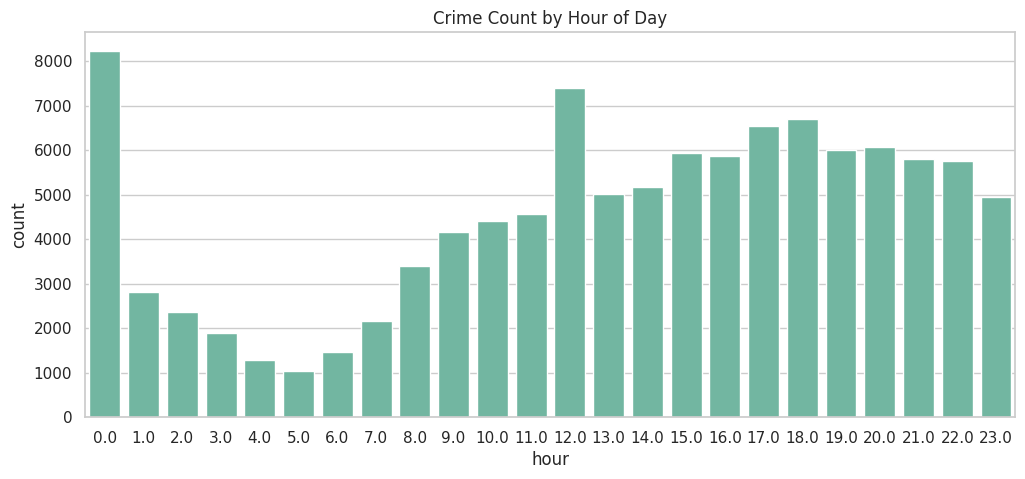

In [15]:
plt.figure(figsize=(12,5))
sns.countplot(x='hour', data=df)
plt.title("Crime Count by Hour of Day")
plt.show()

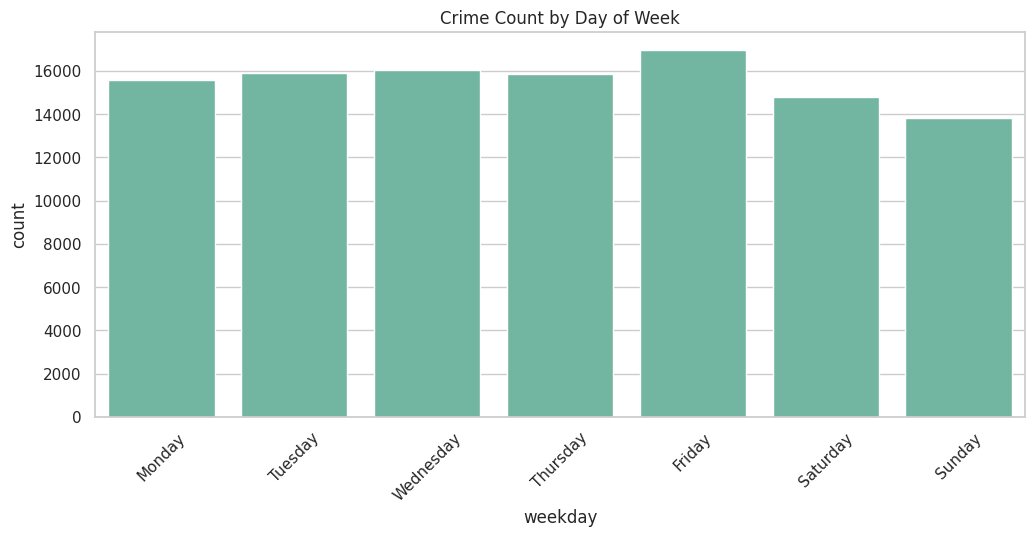

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(x='weekday', data=df, order=[
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])
plt.title("Crime Count by Day of Week")
plt.xticks(rotation=45)
plt.show()

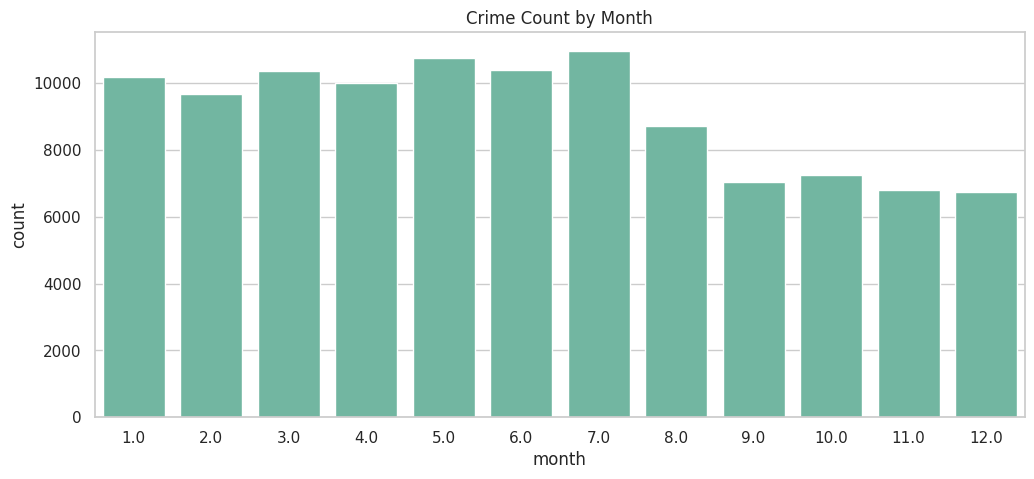

In [17]:
plt.figure(figsize=(12,5))
sns.countplot(x='month', data=df)
plt.title("Crime Count by Month")
plt.show()

## 4. Which types of crimes are most common?
_Theory Link: Rational Choice Theory — theft is low-risk, high-reward → often most common crime._

In [24]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Crime Name1': 'crime_name1'
})

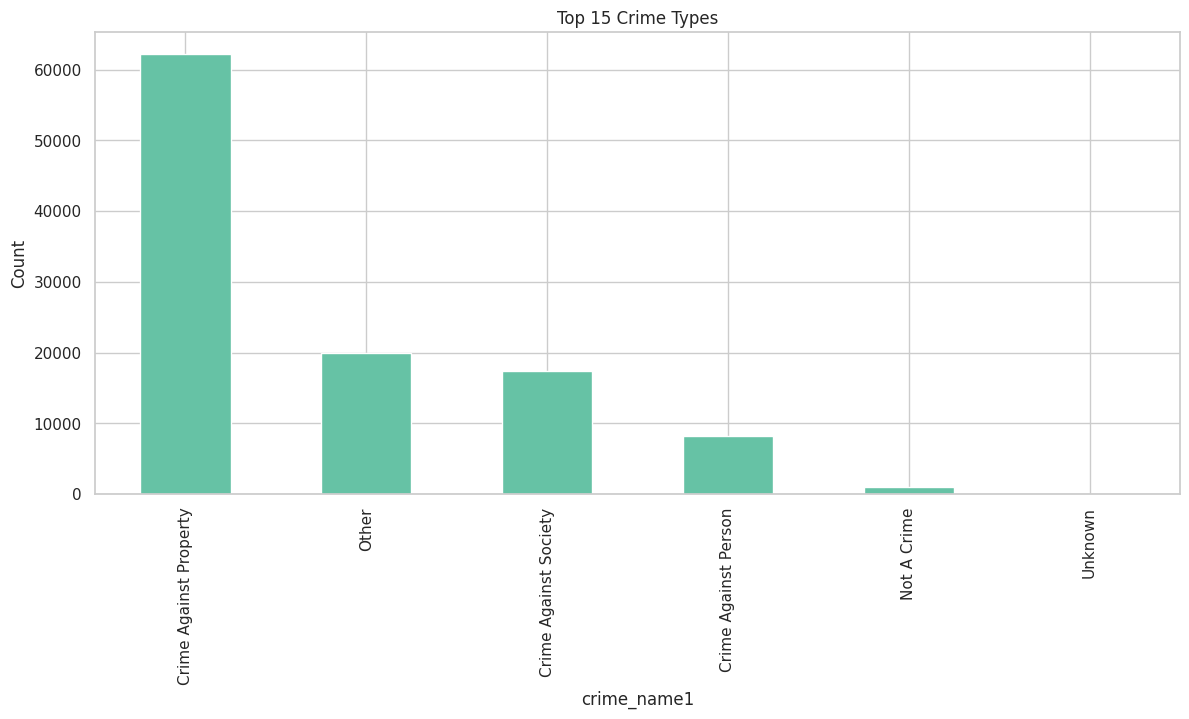

In [25]:
plt.figure(figsize=(14,6))
df['crime_name1'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Crime Types")
plt.ylabel("Count")
plt.show()

## 5. Annual Trends (2018–2022)
_Theory Link: Strain Theory — social stress (e.g., COVID-19) can increase certain crimes._

In [27]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Incident ID': 'incident_id',
})

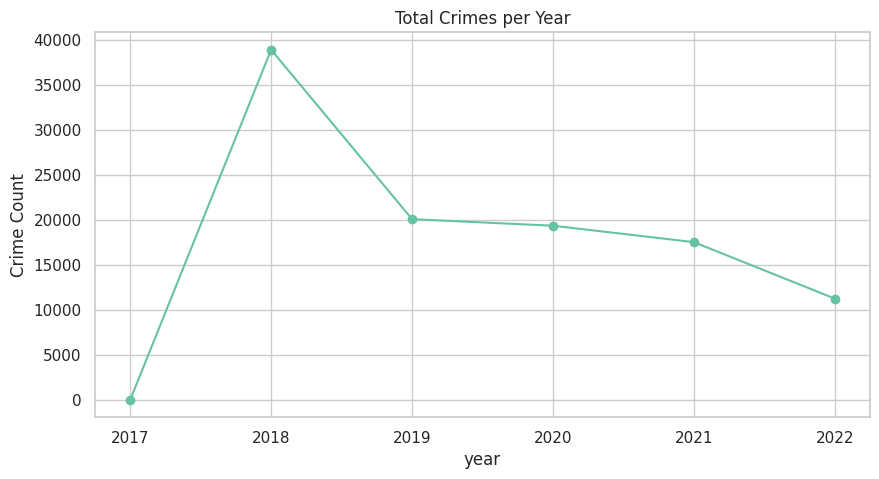

In [28]:
yearly = df.groupby("year")['incident_id'].count()
plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title("Total Crimes per Year")
plt.ylabel("Crime Count")
plt.show()

## 3. When do crimes occur most frequently?
_Theory Link: Routine Activities Theory — crime increases when offenders, targets, and lack of guardianship overlap._

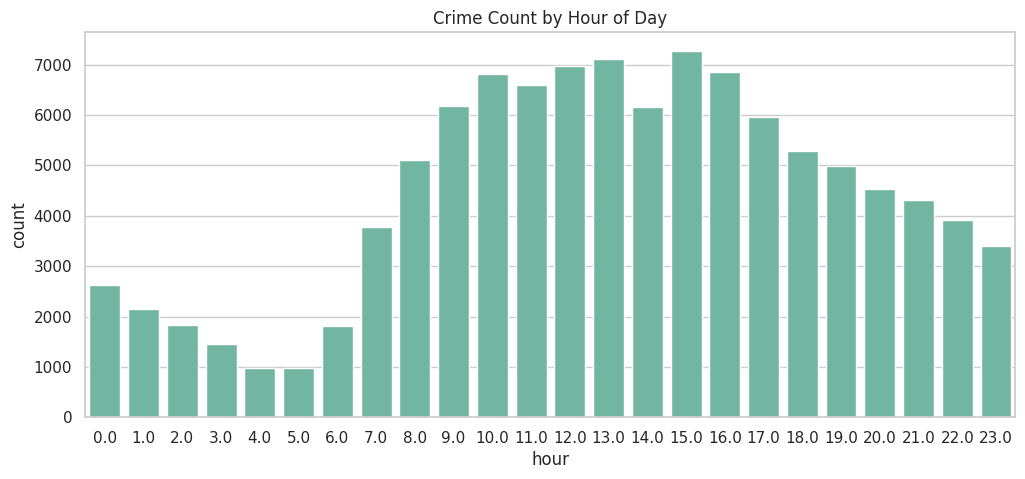

In [29]:
plt.figure(figsize=(12,5))
sns.countplot(x='hour', data=df)
plt.title("Crime Count by Hour of Day")
plt.show()

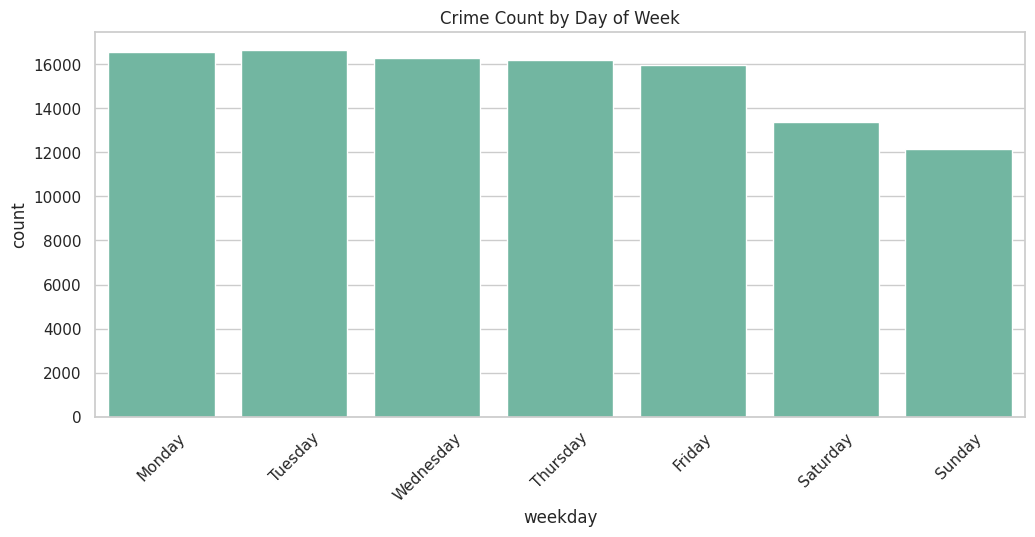

In [30]:
plt.figure(figsize=(12,5))
sns.countplot(x='weekday', data=df, order=[
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])
plt.title("Crime Count by Day of Week")
plt.xticks(rotation=45)
plt.show()

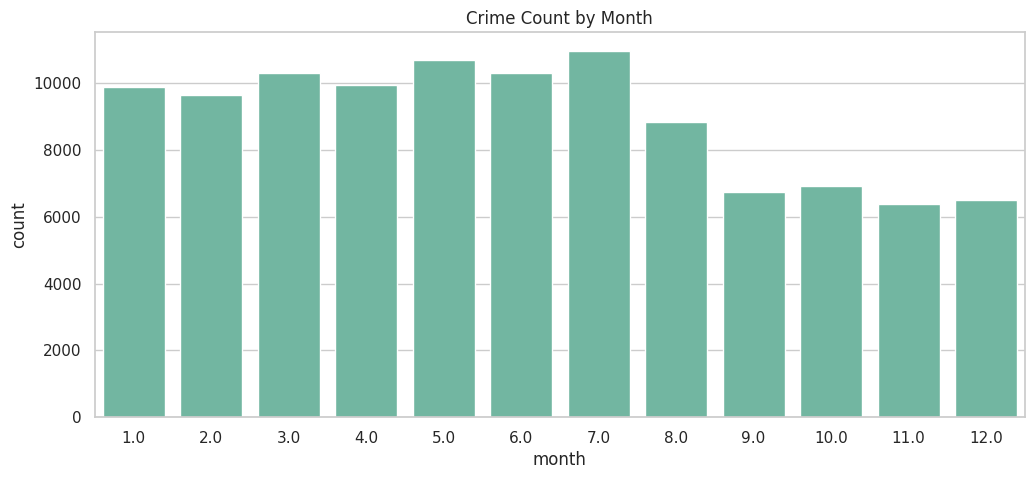

In [31]:
plt.figure(figsize=(12,5))
sns.countplot(x='month', data=df)
plt.title("Crime Count by Month")
plt.show()

## 4. Which types of crimes are most common?
_Theory Link: Rational Choice Theory — theft is low-risk, high-reward → often most common crime._

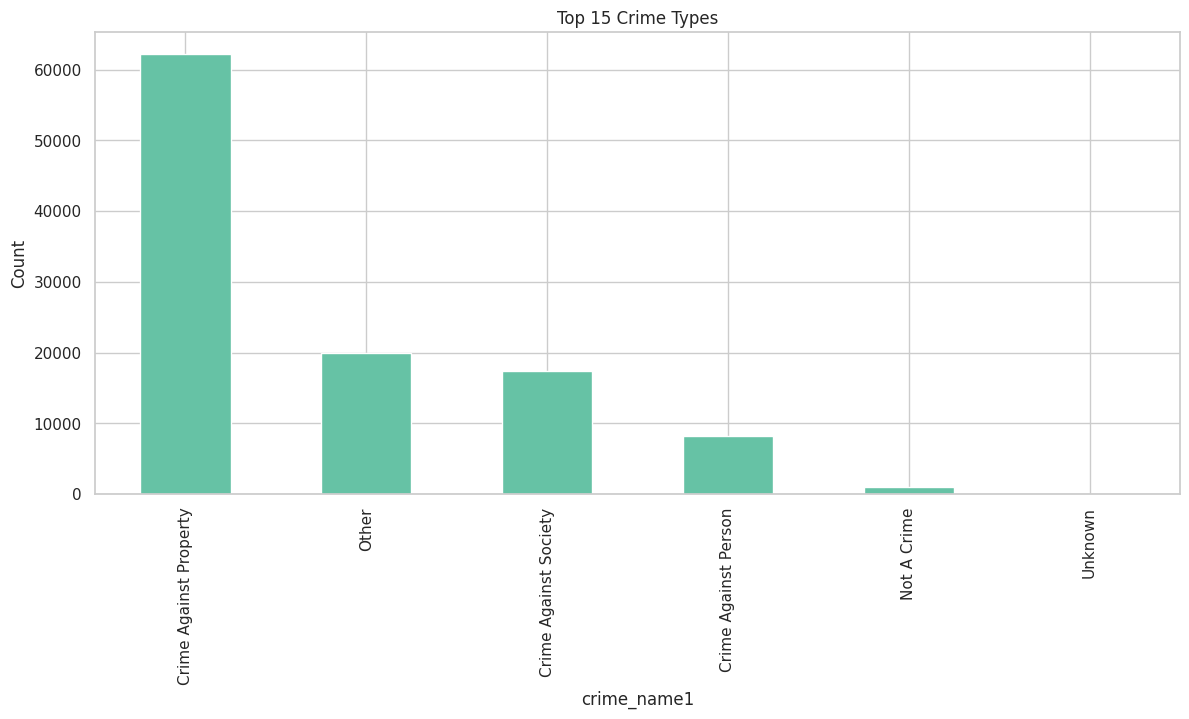

In [32]:
plt.figure(figsize=(14,6))
df['crime_name1'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Crime Types")
plt.ylabel("Count")
plt.show()

## 5. Annual Trends (2018–2022)
_Theory Link: Strain Theory — social stress (e.g., COVID-19) can increase certain crimes._

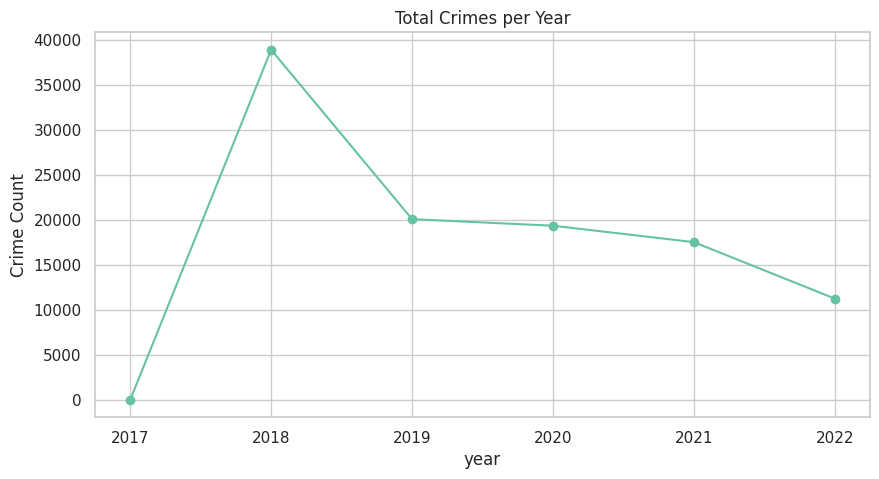

In [34]:
yearly = df.groupby("year")['incident_id'].count()
plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title("Total Crimes per Year")
plt.ylabel("Crime Count")
plt.show()

## 6. Which cities report the highest crime?
_Theory Link: Social Disorganization Theory — high-density, high-mobility areas show more crime._

In [36]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'City': 'city',
})

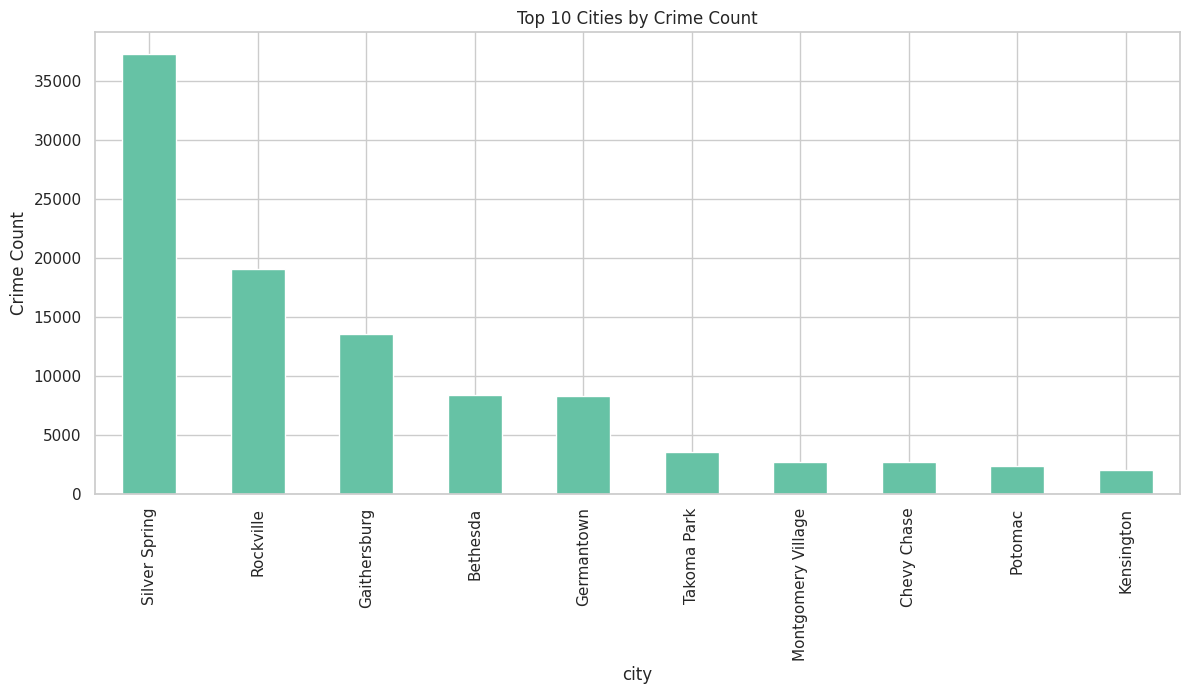

In [37]:
plt.figure(figsize=(14,6))
df['city'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cities by Crime Count")
plt.ylabel("Crime Count")
plt.show()

In [46]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'lat': 'latitude',
    'lon': 'longitude',
})

In [48]:
fig = px.density_mapbox(
    df, lat='latitude', lon='longitude',
    radius=10, zoom=9,
    mapbox_style='carto-positron'
)
fig.show()

## 7. How does location type affect crime?
_Theory Links:_
- _Rational Choice Theory — high-opportunity locations attract property crime._
- _Feminist Criminology — gender-based crimes cluster in private/residential spaces._

In [50]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Place': 'place',
})

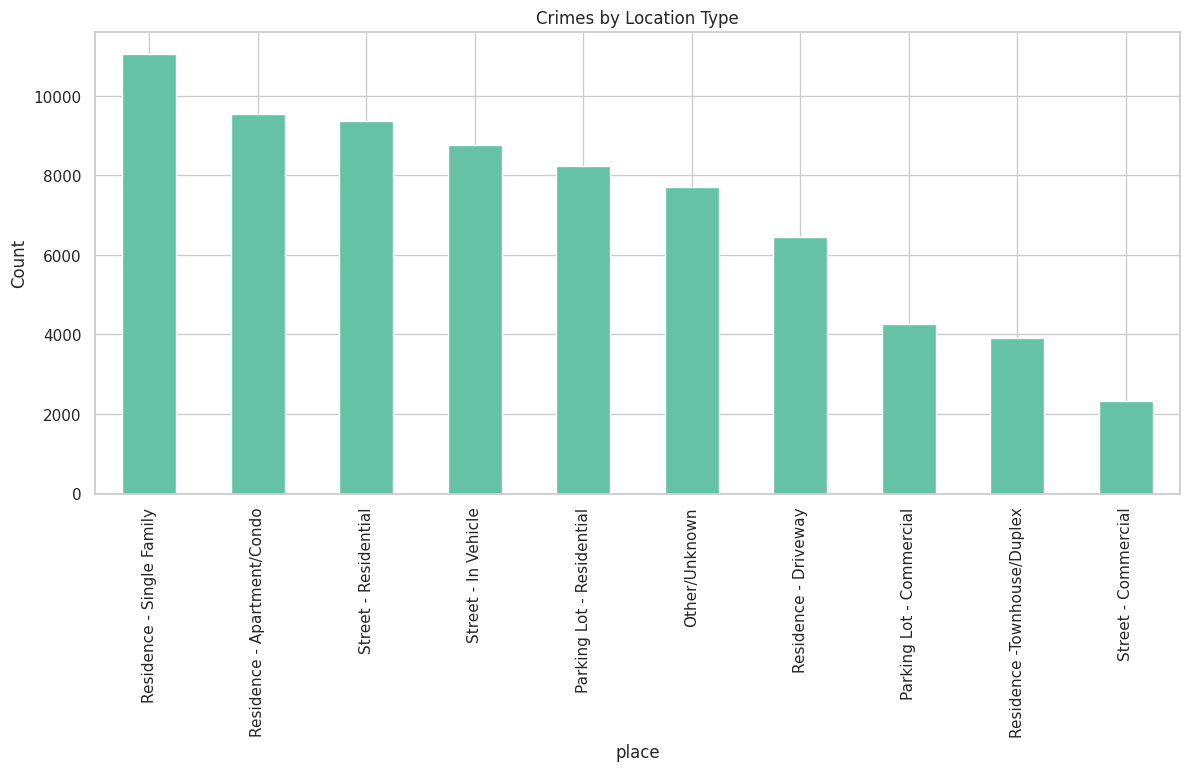

In [51]:
plt.figure(figsize=(14,6))
df['place'].value_counts().head(10).plot(kind='bar')
plt.title("Crimes by Location Type")
plt.ylabel("Count")
plt.show()

## 8. Which police districts handle the most incidents?
_Theory Link: Hotspot + Social Disorganization — districts with more density/commercial areas have higher workload._

In [53]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Police District Number': 'police_district_number',
})

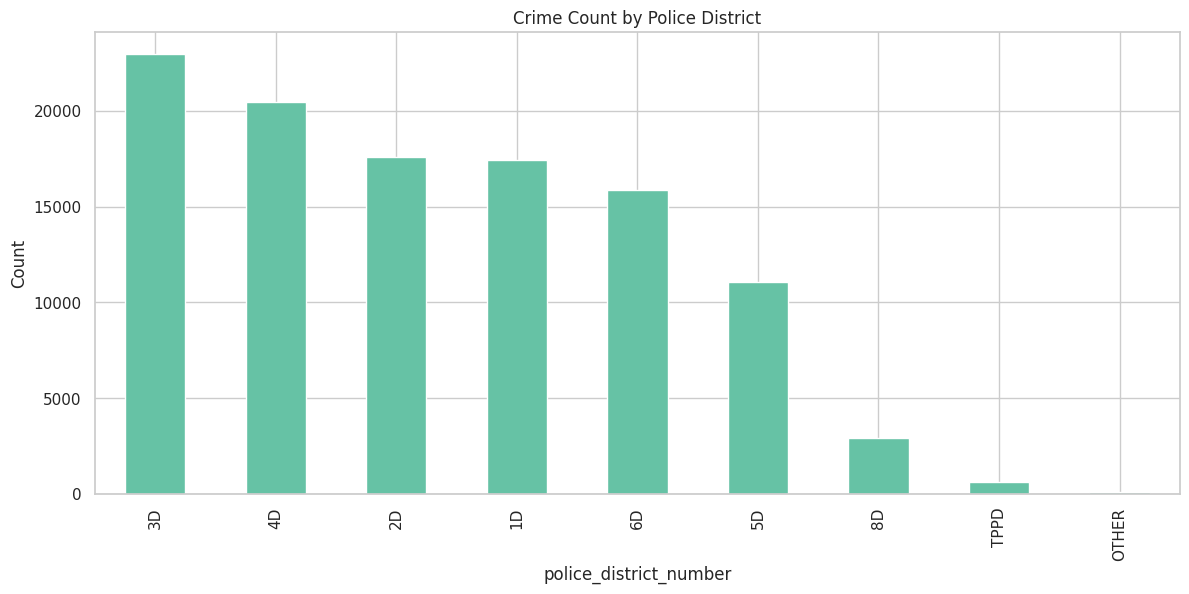

In [54]:
plt.figure(figsize=(14,6))
df['police_district_number'].value_counts().plot(kind='bar')
plt.title("Crime Count by Police District")
plt.ylabel("Count")
plt.show()

## 9. Crime type by time of day
_Theory Link: Routine Activities Theory — crime types follow human activity cycles._

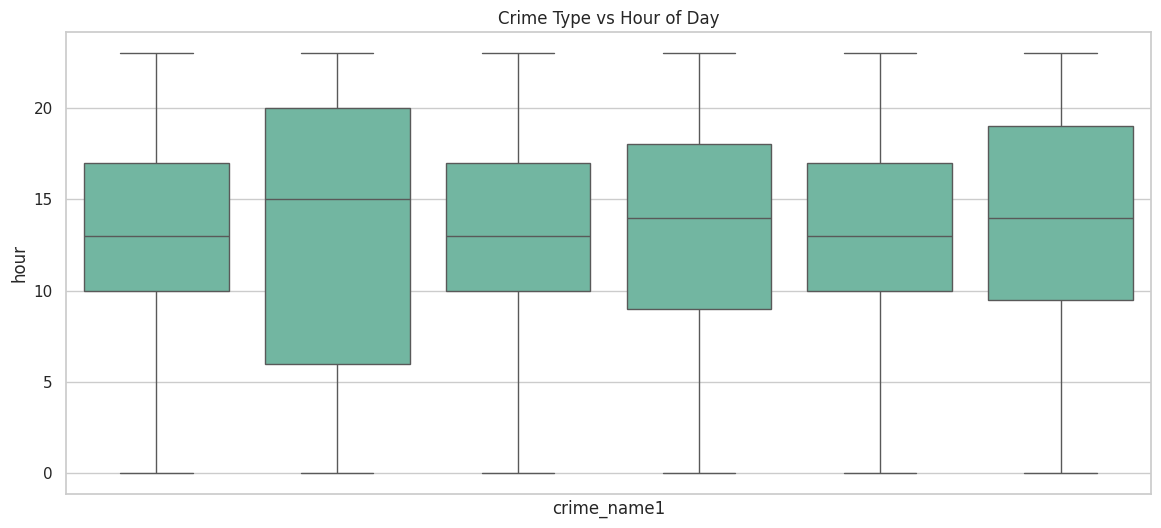

In [56]:
plt.figure(figsize=(14,6))
sns.boxplot(x='crime_name1', y='hour', data=df)
plt.xticks([], [])  # hide labels if too many values
plt.title("Crime Type vs Hour of Day")
plt.show()

## 10. Victims per incident
_Theory Link: NIBRS Victim Pattern Theory — most incidents involve one victim._

In [59]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Victims': 'victims',
})

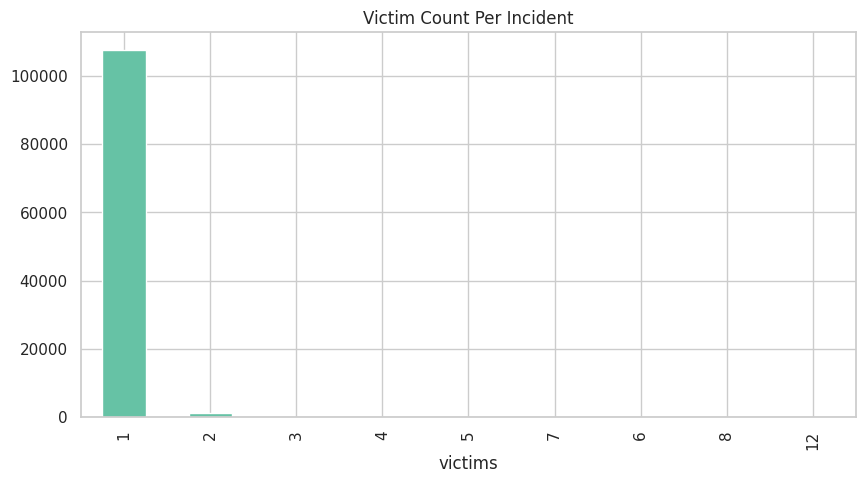

In [60]:
df['victims'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Victim Count Per Incident")
plt.show()

In [61]:
df.to_csv("crime_clean_processed.csv", index=False)